In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score

In [4]:
# 1. TẢI DỮ LIỆU (Dựa trên cấu trúc UCI Mushroom)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = [
    "class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]
df = pd.read_csv(url, names=columns)

In [5]:
# 2. TIỀN XỬ LÝ (Theo Methodology của nhóm)
# Loại bỏ 'veil-type' vì chỉ có 1 giá trị (zero-variance)
df.drop('veil-type', axis=1, inplace=True)

# Xử lý giá trị thiếu '?' trong 'stalk-root' thành 'Unknown'
df['stalk-root'] = df['stalk-root'].replace('?', 'Unknown')

# Tách X, y
X = df.drop('class', axis=1)
y = df['class'].map({'e': 0, 'p': 1}) # e: edible (0), p: poisonous (1)

In [6]:
# 3. ONE-HOT ENCODING (Tạo ra không gian 116 chiều)
encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(X)
feature_names = encoder.get_feature_names_out()

# 4. CHIA DỮ LIỆU (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [7]:
# 5. HUẤN LUYỆN MÔ HÌNH
# Logistic Regression với L1 (Lasso) để tự động chọn đặc trưng
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lr_l1.fit(X_train, y_train)

LogisticRegression(penalty='l1', random_state=42, solver='liblinear')

In [8]:
# Linear SVC để tìm hyperplane tối ưu
svc = LinearSVC(random_state=42, max_iter=10000)
svc.fit(X_train, y_train)

LinearSVC(max_iter=10000, random_state=42)

In [9]:
# 6. ĐÁNH GIÁ (Focus vào Recall cho Poisonous)
def report_results(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Recall (Safety): {rec:.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

report_results(lr_l1, "Logistic Regression (L1)")
report_results(svc, "Linear SVC")


--- Logistic Regression (L1) ---
Accuracy: 1.0000 | Recall (Safety): 1.0000
Confusion Matrix:
[[843   0]
 [  0 782]]

--- Linear SVC ---
Accuracy: 1.0000 | Recall (Safety): 1.0000
Confusion Matrix:
[[843   0]
 [  0 782]]


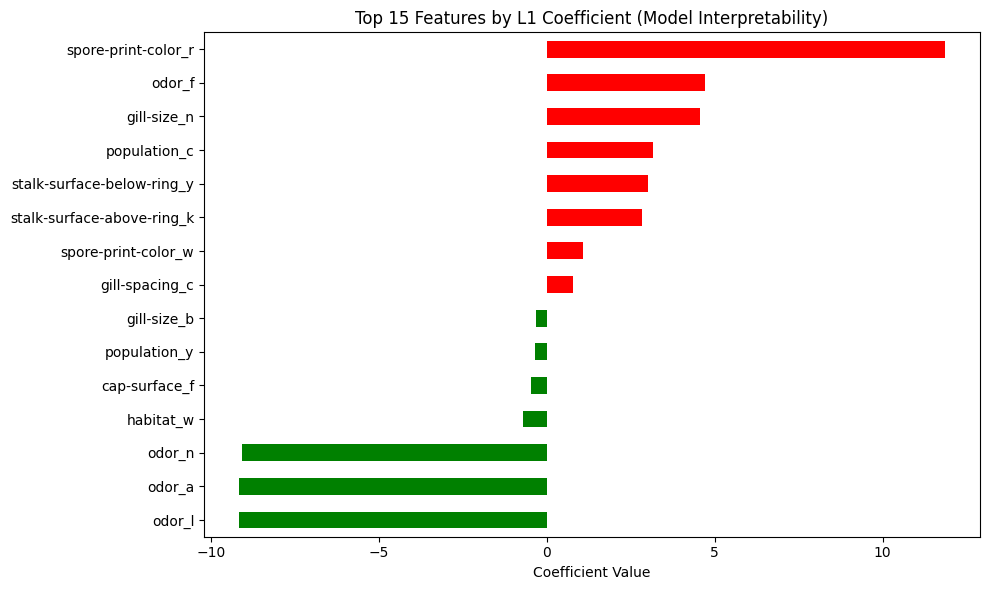

In [10]:
# 7. GIẢI THÍCH MÔ HÌNH (L1 Coefficients)
# Tìm các đặc trưng quan trọng nhất (Top Red Flags)
coefs = lr_l1.coef_[0]
importance = pd.Series(coefs, index=feature_names).sort_values()

plt.figure(figsize=(10, 6))
# Lấy 7 cái thấp nhất (Edible markers) và 8 cái cao nhất (Poisonous markers)
top_plot = pd.concat([importance.head(7), importance.tail(8)])
top_plot.plot(kind='barh', color=['green' if x < 0 else 'red' for x in top_plot])
plt.title("Top 15 Features by L1 Coefficient (Model Interpretability)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()